In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [117]:
df = pd.read_csv("../data/daangn_nintendo_cleaned.csv")

In [118]:
print(df.head())


    gu dong                               title  \
0  강남구  청담동                 닌텐도 스위치 KORG Gadget   
1  강남구  청담동              닌텐도 스위치 마리오카트 8 디럭스 세트   
2  강남구  청담동                         닌텐도 스위치 풀구성   
3  강남구  청담동  (사진구성대로 드려요) 닌텐도 스위치 배터리개선 네온블루/레드   
4  강남구  청담동                 닌텐도 스위치 OLED 젤다 에디션   

                                                link status  is_OLED  is_Lite  \
0  https://www.daangn.com/kr/buy-sell/%EB%8B%8C%E...    판매중    False    False   
1  https://www.daangn.com/kr/buy-sell/%EB%8B%8C%E...   판매완료    False    False   
2  https://www.daangn.com/kr/buy-sell/%EB%8B%8C%E...   판매완료    False    False   
3  https://www.daangn.com/kr/buy-sell/%EC%82%AC%E...    판매중    False    False   
4  https://www.daangn.com/kr/buy-sell/%EB%8B%8C%E...    판매중     True    False   

   is_Edition  price_clean                                            content  \
0       False       110000  국내 발매안한 닌텐도 스위치용 시퀀싱 프로그램인 korg gadget 입니다 내장 ...   
1       False       230000  닌텐도 스위치 마리오카트 8 

In [119]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2787 entries, 0 to 2786
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   gu           2787 non-null   object
 1   dong         2787 non-null   object
 2   title        2787 non-null   object
 3   link         2787 non-null   object
 4   status       2787 non-null   object
 5   is_OLED      2787 non-null   bool  
 6   is_Lite      2787 non-null   bool  
 7   is_Edition   2787 non-null   bool  
 8   price_clean  2787 non-null   int64 
 9   content      2772 non-null   object
 10  posted_time  2772 non-null   object
 11  is_Set       2787 non-null   bool  
dtypes: bool(4), int64(1), object(7)
memory usage: 185.2+ KB
None


In [121]:
def detect_set(row):
    text = (str(row['title']) + ' ' + str(row['content'])).lower()
    keywords_set = ['세트', '풀셋', '풀박', '풀구성', '일괄', '같이', '+', '게임 포함']
    return any(keyword in text for keyword in keywords_set)

df['is_Set'] = df.apply(detect_set, axis=1)

df['is_Lite']    = df['title'].str.contains('Lite|lite|라이트', case=False, na=False)

In [122]:
df.to_csv("../data/daangn_nintendo_cleaned.csv", index=False)

In [123]:
df = df[(df['price_clean'] >= 100000) & (df['price_clean'] <= 500000)]

In [124]:
print(df['price_clean'].describe())

count     2,763
mean    246,180
std      79,831
min     100,000
25%     190,000
50%     250,000
75%     300,000
max     500,000
Name: price_clean, dtype: float64


In [125]:
df['price_clean'] = df['price_clean'].astype(int)

In [126]:
print(df['price_clean'].describe())

count     2,763
mean    246,180
std      79,831
min     100,000
25%     190,000
50%     250,000
75%     300,000
max     500,000
Name: price_clean, dtype: float64


In [127]:
df[['price_clean', 'is_Set', 'is_OLED', 'is_Lite', 'is_Edition']].head()

,price_clean,is_Set,is_OLED,is_Lite,is_Edition
0,110000,False,False,False,False
1,230000,True,False,False,False
2,250000,True,False,False,False
3,200000,False,False,False,False
4,250000,False,True,False,True


In [86]:
# =================================================================================

In [87]:
# 제품별 가격 차이 계산

In [128]:
def calculate_set_difference(df, product_col: str, label: str):
    target = df[df[product_col] == 1]
    grouped = target.groupby('is_Set')['price_clean'].mean()

    single_price = grouped.get(0, float('nan'))
    set_price = grouped.get(1, float('nan'))
    price_diff = set_price - single_price if pd.notnull(set_price) and pd.notnull(single_price) else None

    return {
        '제품명': label,
        '단품 평균': round(single_price) if pd.notnull(single_price) else None,
        '세트 평균': round(set_price) if pd.notnull(set_price) else None,
        '가격 차이': round(price_diff) if price_diff is not None else None
    }

oled_result = calculate_set_difference(df, 'is_OLED', 'OLED')
lite_result = calculate_set_difference(df, 'is_Lite', 'Lite')
edition_result = calculate_set_difference(df, 'is_Edition', 'Edition')

diff_df = pd.DataFrame([oled_result, lite_result, edition_result])
print(diff_df)


       제품명   단품 평균   세트 평균  가격 차이
0     OLED  302609  314793  12184
1     Lite  144440  166774  22334
2  Edition  238652  261664  23013


/var/folders/cf/gnzk5q4j3632j__pxxvtkjlh0000gn/T/ipykernel_5660/1092463048.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  single_price = grouped.get(0, float('nan'))
/var/folders/cf/gnzk5q4j3632j__pxxvtkjlh0000gn/T/ipykernel_5660/1092463048.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  set_price = grouped.get(1, float('nan'))


In [85]:
# ========================================================================================

In [88]:
# 구별 단품 가격 평균 계산

In [129]:
single_df = df[df['is_Set'] == 0]
gu_single_stats = (
    single_df
    .groupby('gu')
    .agg(평균_가격=('price_clean', 'mean'),
         매물_수=('price_clean', 'count'))
    .round(0)
    .reset_index()
    .sort_values(by='평균_가격', ascending=False)
)


In [130]:
print(gu_single_stats)

     gu   평균_가격  매물_수
1  부산진구 236,654   355
0   강남구 229,816   353
2   분당구 227,531   312


In [104]:
# ====================================================================================

In [131]:
# 요일별 단품 평균 거래 

df['posted_time'] = pd.to_datetime(df['posted_time'], errors='coerce')
single_df = df[df['is_Set'] == 0].copy()
single_df['weekday'] = single_df['posted_time'].dt.weekday

weekday_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
single_df['weekday'] = single_df['weekday'].map(weekday_map)

# OLED
oled = single_df[single_df['is_OLED'] == 1]
oled_grouped = oled.groupby('weekday')['price_clean'].mean().round(0).reset_index()
oled_grouped.columns = ['weekday', 'OLED_평균가']

# Lite
lite = single_df[single_df['is_Lite'] == 1]
lite_grouped = lite.groupby('weekday')['price_clean'].mean().round(0).reset_index()
lite_grouped.columns = ['weekday', 'Lite_평균가']

# Edition
edition = single_df[single_df['is_Edition'] == 1]
edition_grouped = edition.groupby('weekday')['price_clean'].mean().round(0).reset_index()
edition_grouped.columns = ['weekday', 'Edition_평균가']

merged = oled_grouped.merge(lite_grouped, on='weekday', how='outer')
merged = merged.merge(edition_grouped, on='weekday', how='outer')

weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
merged['weekday'] = pd.Categorical(merged['weekday'], categories=weekday_order, ordered=True)
merged = merged.sort_values('weekday').reset_index(drop=True)

print(merged)

  weekday  OLED_평균가  Lite_평균가  Edition_평균가
0     Mon   300,633   135,875      268,684
1     Tue   311,294   141,633      233,048
2     Wed   293,068   144,545      221,818
3     Thu   302,955   149,484      243,500
4     Fri   303,438   140,345      224,600
5     Sat   304,115   154,038      256,250
6     Sun   300,721   142,167      220,652


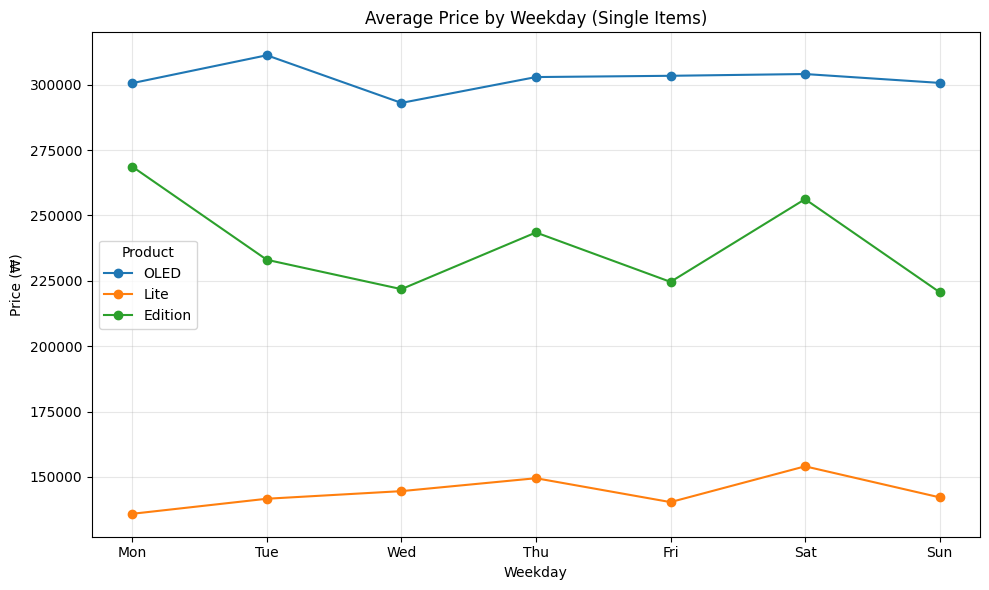

In [132]:
plt.figure(figsize=(10,6))
for col in ['OLED_평균가', 'Lite_평균가', 'Edition_평균가']:
    plt.plot(merged['weekday'], merged[col], marker='o', label=col.replace('_평균가',''))

plt.title('Average Price by Weekday (Single Items)')
plt.xlabel('Weekday')
plt.ylabel('Price (₩)')
plt.legend(title='Product')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [116]:
# ==================================================================================================================